In [1]:
import nltk
import numpy as np
import pandas as pd
import os
import re
import string
import Basic_functions as bf  #Homemade script.
import time
import matplotlib.pyplot as plt


from nltk import word_tokenize
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, RandomizedSearchCV 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from nltk.stem import SnowballStemmer

import torch
import torch.nn as nn
import torch.optim as optim

###################################################

#https://gist.github.com/berteltorp/0cf8a0c7afea7f25ed754f24cfc2467b Stopords liste
stopwords_danish = np.genfromtxt(r"txt_files\\stopord.txt", dtype = "str", encoding="utf-8")
default_stopwords = set(stopwords.words('english'))

extended_stopwords = default_stopwords.union(stopwords_danish)

print('Packages loaded')

Packages loaded


<h1> Importing the files.</h1>
for 36000 files, takes roughly 7 minuttes

In [7]:
#test = open("Speeches\A._Bartholdy_Møllers_prædiken_1._søndag_efter_paske.txt", "r", encoding="utf-8").read().strip()

def import_txt_files_to_array(folder_path):
    txt_files_content = []
    txt_year          = []
    Files_read = 0
    
    for i in folder_path:
        for filename in os.listdir(i): #folder_path):
            if filename.endswith('.txt'):
                Files_read = Files_read + 1
                file_path = os.path.join(i, filename) #folder_path, filename)
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        content = file.read()
                        # Split at the first occurrence of "\n\n\n" and take the part after it
                        parts = content.split('\n\n', 1)
                        if len(parts) > 1:
                            text_after_marker = parts[1]
                        else:
                            text_after_marker = content  # Fallback if "\n\n\n" not found
    
                        # Replace escaped newlines (\\n) with spaces, then remove all newlines
                        text_after_marker = text_after_marker.replace('\\n', ' ').replace('\n', ' ')
    
                        # Convert to lowercase, keep letters (including æøå), spaces, and remove ellipses
                        cleaned_text = re.sub(r'[^a-zA-ZæøåÆØÅ\s]', '', text_after_marker.lower())
                        cleaned_text = cleaned_text.replace("'", "")
                        cleaned_text = cleaned_text.replace('...', '')  # Remove ellipses
    
                        # Remove extra spaces (e.g., multiple spaces)
                        cleaned_text = ' '.join(cleaned_text.split())
    
                        txt_files_content.append(cleaned_text)
    
    
                        ############################################
    
                        year_part = content.split('\n', 2)
                        year_after_marker = (year_part[1].split('-',1))[0]
                        cleaned_year = year_after_marker.replace('Date: ', "")
                        try:
                            txt_year.append(float(cleaned_year))
                        except:
                            txt_year.append(0)
                        
                except Exception as e:
                    print(f"Error reading {filename}: {e}")
    print('Files read:', Files_read)

    return  pd.DataFrame(txt_files_content, columns = ['text']), pd.DataFrame(txt_year, columns = ['year'])

# Example usage:

start = time.time()

folder_path = [r'Speeches', r'articles']  # Replace with your folder path
df, df_year = import_txt_files_to_array(folder_path) 

stop = time.time()
print(f'done, time taken {(stop-start)/60:3f} minuttes' )


#skip = test.find('\n\n\n')
#Raw_test = test[skip:].lower()

#nltk.download('all')


Files read: 36226
done, time taken 0.226033 minuttes


<h3> Divide into a period?</h3>

<h1> Preprocessing the files</h1>
takes roughly 192.493180 seconds

In [10]:
def preprocess(text, min_word_length=3, max_word_length=30):
    
    stemmer = SnowballStemmer(language='danish')
    
    tokens = word_tokenize(text, language = 'danish', preserve_line=False)

    tokens = [
        word for word in tokens
        if (word.isalpha() and
            word not in string.punctuation and
            min_word_length <= len(word) <= max_word_length)
    ]
    
    tokens = [word for word in tokens if word.isalpha() and word not in extended_stopwords]
    
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)
    

####################################

start = time.time()

df_clean = pd.DataFrame({
    'text': df['text'].apply(preprocess),
    #'auth': df_Author['Author'],
    'year': df_year['year']
})

    
stop = time.time()

print(f'Time preprocessing: {(stop-start)/60:3f} minuttes')

Time preprocessing: 2.222171 minuttes


In [11]:
df_clean

,text,year
0,landsmænd dansk student fædreland skyld udret ...,1942.0
1,udpræg centralt skøn evangelium kristus saml f...,1945.0
2,syndsforlad naad fortælling jesu mød synderind...,1944.0
3,ord indehold her forjæt jesus gav discipl foru...,1945.0
4,god livsråd grønland fremtid bær ansvar ældr g...,2025.0
...,...,...
36221,,2001.0
36222,eus udvid øst kost dansk nogenlund forlæng bar...,2002.0
36223,størst mord menneske histori lød drillegåd bør...,2001.0
36224,nykping politik mandag land optag ind borg nyd...,2001.0


In [12]:
print(df_clean['text'], '\n\n')
print(df['text'])

0        landsmænd dansk student fædreland skyld udret ...
1        udpræg centralt skøn evangelium kristus saml f...
2        syndsforlad naad fortælling jesu mød synderind...
3        ord indehold her forjæt jesus gav discipl foru...
4        god livsråd grønland fremtid bær ansvar ældr g...
                               ...                        
36221                                                     
36222    eus udvid øst kost dansk nogenlund forlæng bar...
36223    størst mord menneske histori lød drillegåd bør...
36224    nykping politik mandag land optag ind borg nyd...
36225    ravn matematik sikkert svært middagsselskab ta...
Name: text, Length: 36226, dtype: object 


0        landsmænd og danske studenter sit fædreland sk...
1        der er noget udpræget centralt over dette skøn...
2        syndsforladelsens naade med fortællingen om je...
3        disse ord indeholder en herlig forjættelse som...
4        ti gode livsråd du er grønlands fremtid men du...
            

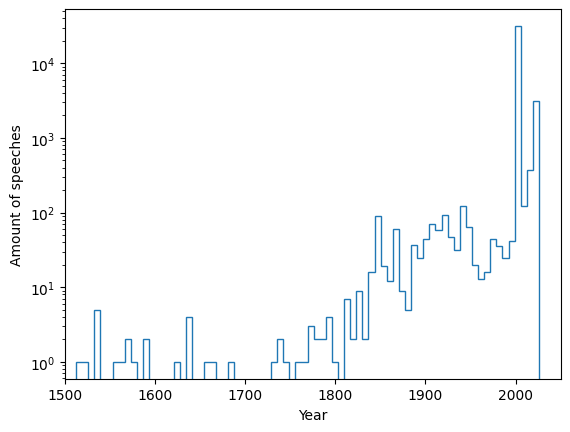

In [13]:
plt.hist(df_clean['year'], bins = 300, histtype = 'step')
plt.yscale('log')
plt.xlim(1500,2050)
plt.xlabel('Year')
plt.ylabel('Amount of speeches')
plt.show()

<h1> Embedding the data</h1>
TF_IDF turns the words into a sparse matrix, weighing the words. Biased by text length, though.

In [212]:
from scipy.sparse import hstack, csr_matrix


vectorizer = TfidfVectorizer(use_idf=False, min_df=25, max_df=0.8, lowercase=True, token_pattern=r'(?u)\b[A-Za-zæøå]+\b')
#Term Frequency-Inverse Document Frequency)

#Word2vec is better https://www.geeksforgeeks.org/python/python-word-embedding-using-word2vec/


#X_auth = csr_matrix(df_clean[['auth']].astype(float).values)
#X_text = vectorizer.fit_transform(df_clean['text'])

X = (vectorizer.fit_transform(df_clean['text'])).astype(np.float32) #hstack([X_text, X_auth])
y = df_clean['year']
print("TF-IDF matrix shape:", X.shape) # 174594 words is too much >:( Stemming improved to 112273, removing punctuation and short words: 111767

TF-IDF matrix shape: (36226, 14559)


In [214]:
vectorizer.get_feature_names_out()

array(['aab', 'aabenbar', 'aabenbared', ..., 'øves', 'øvet', 'øvr'],
      dtype=object)

In [218]:
X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 3353894 stored elements and shape (36226, 14559)>

<h1> Dimensionality reduction</h1>

In [220]:
svd = TruncatedSVD(n_components=2,
             algorithm='randomized',
             n_iter=5,
             n_oversamples=10,
             power_iteration_normalizer='auto',
             random_state=42,
             tol=0.0)

start = time.time()

X_LSA = svd.fit_transform(X)
print(svd.explained_variance_ratio_)
print(svd.explained_variance_ratio_.sum())
print(svd.singular_values_)

stop = time.time()
print(f'Done in {stop-start:3f} seconds', '\n')

[0.02990629 0.01579618]
0.045702465
[36.706367 18.3921  ]
Done in 0.334430 seconds 



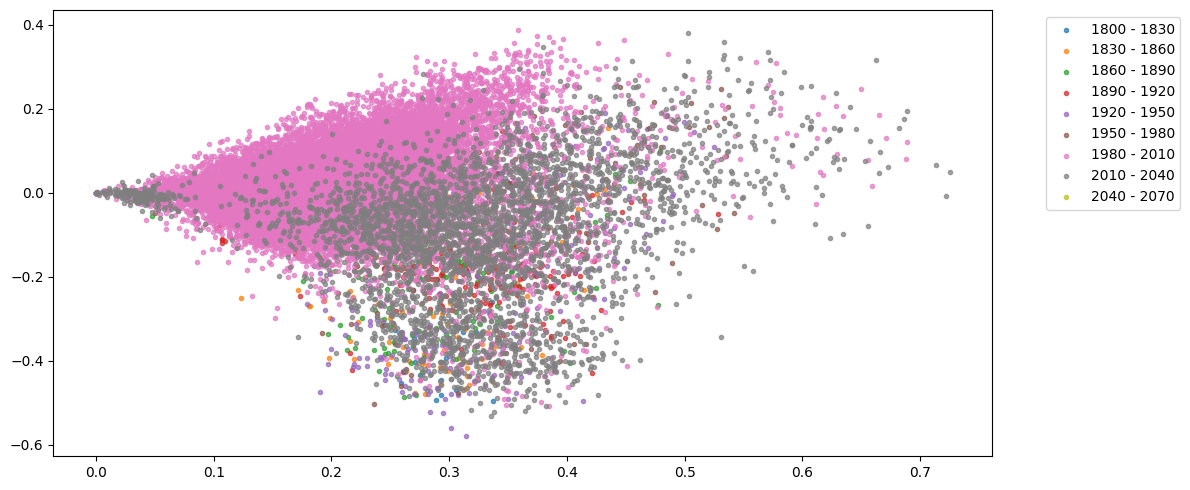

In [222]:
intervals = np.arange(1800,2100,30)

try:
    # Create cutoffs column
    df_clean['cutoffs'] = pd.cut(
        df_clean['year'],
        intervals,
        labels=intervals[:-1],
        right=False
    )

    # Verify the column was created
    if 'cutoffs' not in df_clean.columns:
        raise ValueError("Failed to create 'cutoffs' column")
        
    # Create scatter plot
    plt.figure(figsize=(12, 5))
    for cutoff in df_clean['cutoffs'].cat.categories:
        subX_LSA = X_LSA[df_clean['cutoffs'] == cutoff, :]
        plt.scatter(subX_LSA[:,0], subX_LSA[:,1],marker = '.', label=f'{str(cutoff)} - {str(cutoff + 30)}', alpha=0.7)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error occurred: {str(e)}")
    print("\nDebugging info:")
    print(f"DataFrame columns: {df_clean.columns.tolist()}")
    print(f"DataFrame shape: {df_clean.shape}")
    print(f"Sample of year values: {df_clean['year'].head()}")

[0. 0. 0. ... 1. 1. 1.]


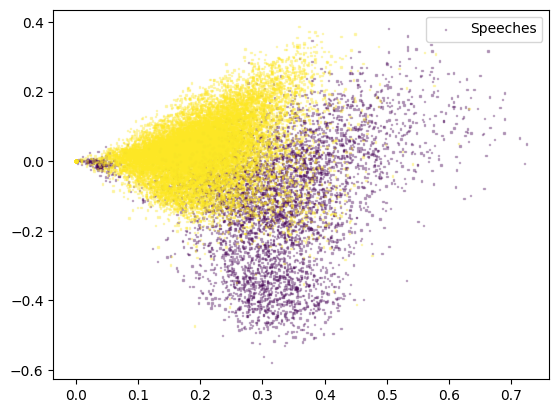

In [225]:
c = np.zeros(36226)
c[4700:] = c[4700:] + 1
print(c)
plt.scatter(X_LSA[:,0], X_LSA[:,1], s = 1, alpha = 0.3, marker = ',', c = c)
plt.legend(['Speeches', 'Articles'])
plt.show()

<h1>XGboost model training</h1>

In [273]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_eval, X_test, y_eval, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [275]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2347741 stored elements and shape (25358, 14559)>

In [278]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
print('running xgboost version:', xgb.__version__)


model = xgb.XGBRegressor(objective='reg:squarederror',
                         eval_metric = 'rmse',
                         importance_type="weight",
                         n_estimators=200,
                         learning_rate=0.30,
                         max_depth = 10,
                         reg_alpha = 0.7,
                         subsample = 1.0,
                         n_jobs = 1,
                         tree_method = 'hist',
                         min_child_weight = 3,
                         #early_stopping_rounds = 50,
                         grow_policy = 'lossguide',
                         max_bin = 64,
                         random_state=42)


start = time.time()

evalset = [(X_train, y_train), (X_eval,y_eval)]

model.fit(X_train, y_train, eval_set= evalset, verbose=0)

stop = time.time()
print(f'Training time: {stop - start:3f} seconds')

y_pred = model.predict(X_eval)

rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

#model.save_model('model.bin')

running xgboost version: 3.0.0
Training time: 595.875210 seconds
RMSE: 8.684
R²: 0.844


In [282]:
y_pred_test = model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print(f'RMSE test: {rmse_test:.3f}')
print(f'R² test: {r2_test:.3f}')

RMSE test: 39.655
R² test: 0.107


In [233]:
model.save_model('model.bin')

C:\Users\Geniet\AppliedML\AppliedML2026\appmlenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [11:44:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)


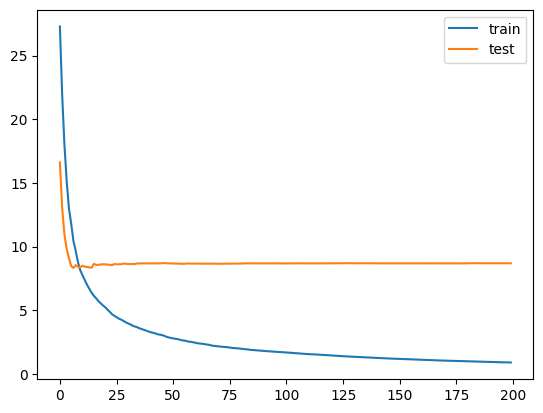

In [284]:
# retrieve performance metrics
results = model.evals_result()

# plot learning curves
plt.plot(results['validation_0']['rmse'], label='train')
plt.plot(results['validation_1']['rmse'], label='test')
# show the legend
plt.legend()
# show the plot
plt.show()

In [286]:
from sklearn.cluster import KMeans
N_cluster = 5
c_cluster = KMeans(n_clusters=N_cluster,
                   n_init = "auto"
                  ).fit_predict(list(zip(y_pred,y_eval)))
print(c_cluster)

Mass_means = []
for i in range(0,N_cluster):
    mean_year = np.array([np.mean(y_pred[c_cluster == i]), np.mean(y_eval[c_cluster == i])])
    Mass_means.append(mean_year)

print(Mass_means)

[0 0 0 ... 0 0 0]
[array([2001.52233887, 2001.09247583]), array([1854.00427246, 1853.87234043]), array([1921.06176758, 1928.86516854]), array([1641.22363281, 1637.6       ]), array([2019.44396973, 2022.23551402])]


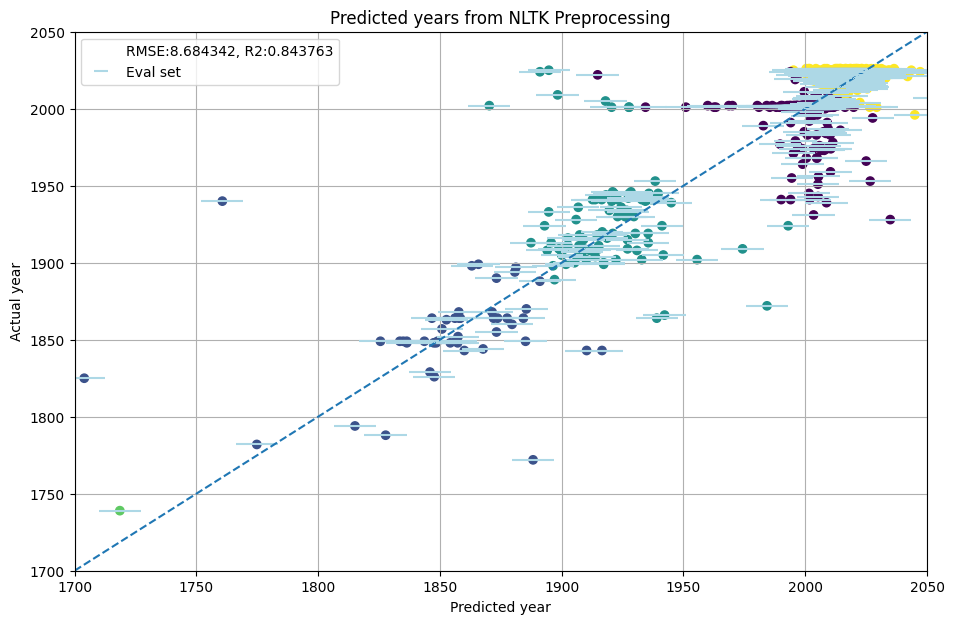

In [306]:

plt.figure(figsize = (11,7))

#plt.plot(y_pred,y_test, '.', label = 'Eval set')
y_train_pred = model.predict(X_train)
#y_test_pred = model.predict(X_test)
#plt.plot(y_train_pred, y_train, '.', alpha = 0.3, c = 'orange', label = 'Train set')
plt.errorbar(y_pred, y_eval, xerr =rmse, fmt = ',', c= 'lightblue', label = 'Eval set')
plt.scatter(y_pred,y_eval, c = c_cluster)
#plt.plot(y_test_pred,y_test, '.', c= 'purple', label = 'Test set')

plt.plot([1700,2050],[1700,2050], '--')
plt.xlabel('Predicted year')
plt.ylabel('Actual year')
plt.xlim(1700,2050)
plt.ylim(1700,2050)

plt.plot([],[], ' ', label = f'RMSE:{rmse:3f}, R2:{r2:3f}')
plt.grid()
plt.title('Predicted years from NLTK Preprocessing')
plt.legend()


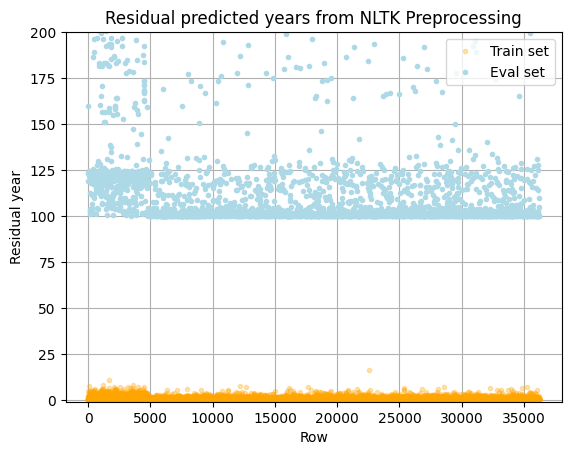

In [308]:
plt.plot(abs(y_train_pred -y_train), '.', alpha = 0.3, c = 'orange', label = 'Train set')
plt.plot(abs(y_pred-y_test)+100, '.', c= 'lightblue', label = 'Eval set')


plt.xlabel('Row')
plt.ylabel('Residual year')
plt.ylim(-1, 200)

plt.grid()
plt.title('Residual predicted years from NLTK Preprocessing')
plt.legend()

Best parameters found:  {'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.22959818254342154), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 88, 'reg_alpha': np.float64(0.44583275285359114), 'reg_lambda': np.float64(0.09997491581800289), 'subsample': np.float64(0.9836995567863469)}